In [1]:
# --- Markdown: ## 1. Imports and Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Import your custom engine and the softplus function
# (Ensure cooltrack.py is in the same directory as this notebook)
from cooltrack.cooltrack import SemiAnalyticalCoolTrack, softplus_piecewise, generalized_sigmoid, sloped_sigmoid
from cooltrack.data_loader import load_grid
from cooltrack.constants import INDEPENDENT_DIMS as independent_dims

# Make plots look nice by default
plt.rcParams.update({
    'font.size': 12, 
    'axes.labelsize': 14, 
    'axes.titlesize': 15, 
    'figure.facecolor': 'white'
})

In [2]:
print("Loading full unstructured grid...")
GRID_PATH = "../../exoweave/outputs/master_grid_cooltrack.h5" 
df = load_grid(GRID_PATH, use_cache=False)  # Use cached version if available for faster loading

# (Optional) If you just updated the HDF5 file and need to force a rebuild:
# df_grid = load_grid(GRID_PATH, use_cache=False)

# Ensure standard column naming
if 'dsdt' not in df.columns and 'dsdt_J_K_kg_s' in df.columns:
    df['dsdt'] = df['dsdt_J_K_kg_s']

# Initialize the engine. 
# Note: We pass None for initial_conditions_model because we are only 
# testing the `fit_surrogate` method right now, not the `evolve` method.
engine = SemiAnalyticalCoolTrack(
    grid_df=df, 
    initial_conditions_model=None, 
    independent_dims=independent_dims, 
    bandwidth=0.5
)
print(f"✅ Engine initialized with {len(engine.grid_df)} valid models.")

2026-05-05 22:38:06,360 - INFO - ⏳ Parquet cache not found or disabled. Running parallel HDF5 extraction...
2026-05-05 22:38:06,361 - INFO - Loading Exoweave HDF5 file: ../../exoweave/outputs/master_grid_cooltrack.h5...


Loading full unstructured grid...


2026-05-05 22:39:05,725 - INFO - Spinning up 47 workers to read HDF5 across network...
Reading HDF5 Chunks: 100%|██████████| 190/190 [00:28<00:00,  6.75it/s]


Extracted 21378 models from Exoweave HDF5 file.


2026-05-05 22:39:46,567 - INFO - ✅ Exoweave Grid loaded and mapped successfully. Final shape: (20999, 301)


✅ Engine initialized with 20999 valid models.


In [3]:
list(df.columns)

['mass',
 'T_int',
 'T_int_input_dial',
 'T_irr',
 'T_eff',
 'Met',
 'core',
 'f_sed_refractory',
 'f_sed_volatile',
 'kzz',
 'Req',
 'dsdt',
 'S_physical',
 'JWST/NIRCam.F070W',
 'JWST/NIRCam.F090W',
 'JWST/NIRCam.F115W',
 'JWST/NIRCam.F140M',
 'JWST/NIRCam.F150W',
 'JWST/NIRCam.F182M',
 'JWST/NIRCam.F200W',
 'JWST/NIRCam.F210M',
 'JWST/NIRCam.F250M',
 'JWST/NIRCam.F277W',
 'JWST/NIRCam.F300M',
 'JWST/NIRCam.F335M',
 'JWST/NIRCam.F356W',
 'JWST/NIRCam.F410M',
 'JWST/NIRCam.F430M',
 'JWST/NIRCam.F444W',
 'JWST/NIRCam.F460M',
 'JWST/NIRCam.F480M',
 'JWST/MIRI.F560W',
 'JWST/MIRI.F770W',
 'JWST/MIRI.F1000W',
 'JWST/MIRI.F1130W',
 'JWST/MIRI.F1280W',
 'JWST/MIRI.F1500W',
 'JWST/MIRI.F1800W',
 'JWST/MIRI.F2100W',
 'JWST/MIRI.F2550W',
 'JWST/NIRISS.F090W',
 'JWST/NIRISS.F115W',
 'JWST/NIRISS.F140M',
 'JWST/NIRISS.F150W',
 'JWST/NIRISS.F158M',
 'JWST/NIRISS.F200W',
 'JWST/NIRISS.F277W',
 'JWST/NIRISS.F380M',
 'JWST/NIRISS.F430M',
 'JWST/NIRISS.F480M',
 'Paranal/SPHERE.IRDIS_B_Y',
 'Paranal/S

In [4]:
# --- Markdown: ## 3. Define Target Planet & Run Fits ---
target_planet = {
    'mass_Mj': 10.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 3.0,  # <-- Need both now!
    'f_sed_volatile': 6.0,    # <-- Need both now! 
    'kzz': 8.0, 
    'T_irr': 100.0
}

# Ensure these match your DataFrame columns exactly
photometry_bands = [
    'log_Keck/NIRC2.J', 
    'log_Paranal/SPHERE.IRDIS_B_H',
    'log_JWST/MIRI.F1130W',
]

print(f"Extracting surrogate fits for: {target_planet}...")
# Run the extraction!
fits = engine.fit_surrogate(target_planet, photometry_bands)

print("✅ Fits extracted successfully!")
print(f"   -> Thermodynamics R2 : {fits['r2_S']:.3f}")
print(f"   -> Cooling Rate R2   : {fits['r2_tau']:.3f}")
print(f"   -> Radius R2         : {fits['r2_R']:.3f}")

Extracting surrogate fits for: {'mass_Mj': 10.0, 'Met': 0.0, 'core': 10.0, 'f_sed_refractory': 3.0, 'f_sed_volatile': 6.0, 'kzz': 8.0, 'T_irr': 100.0}...
Radius fit successful with R²=0.970
Radius fit parameters: [11.3780321   0.86327981  0.12373098  8.30179479  7.05208774]
✅ Fits extracted successfully!
   -> Thermodynamics R2 : 0.983
   -> Cooling Rate R2   : 0.945
   -> Radius R2         : 0.970


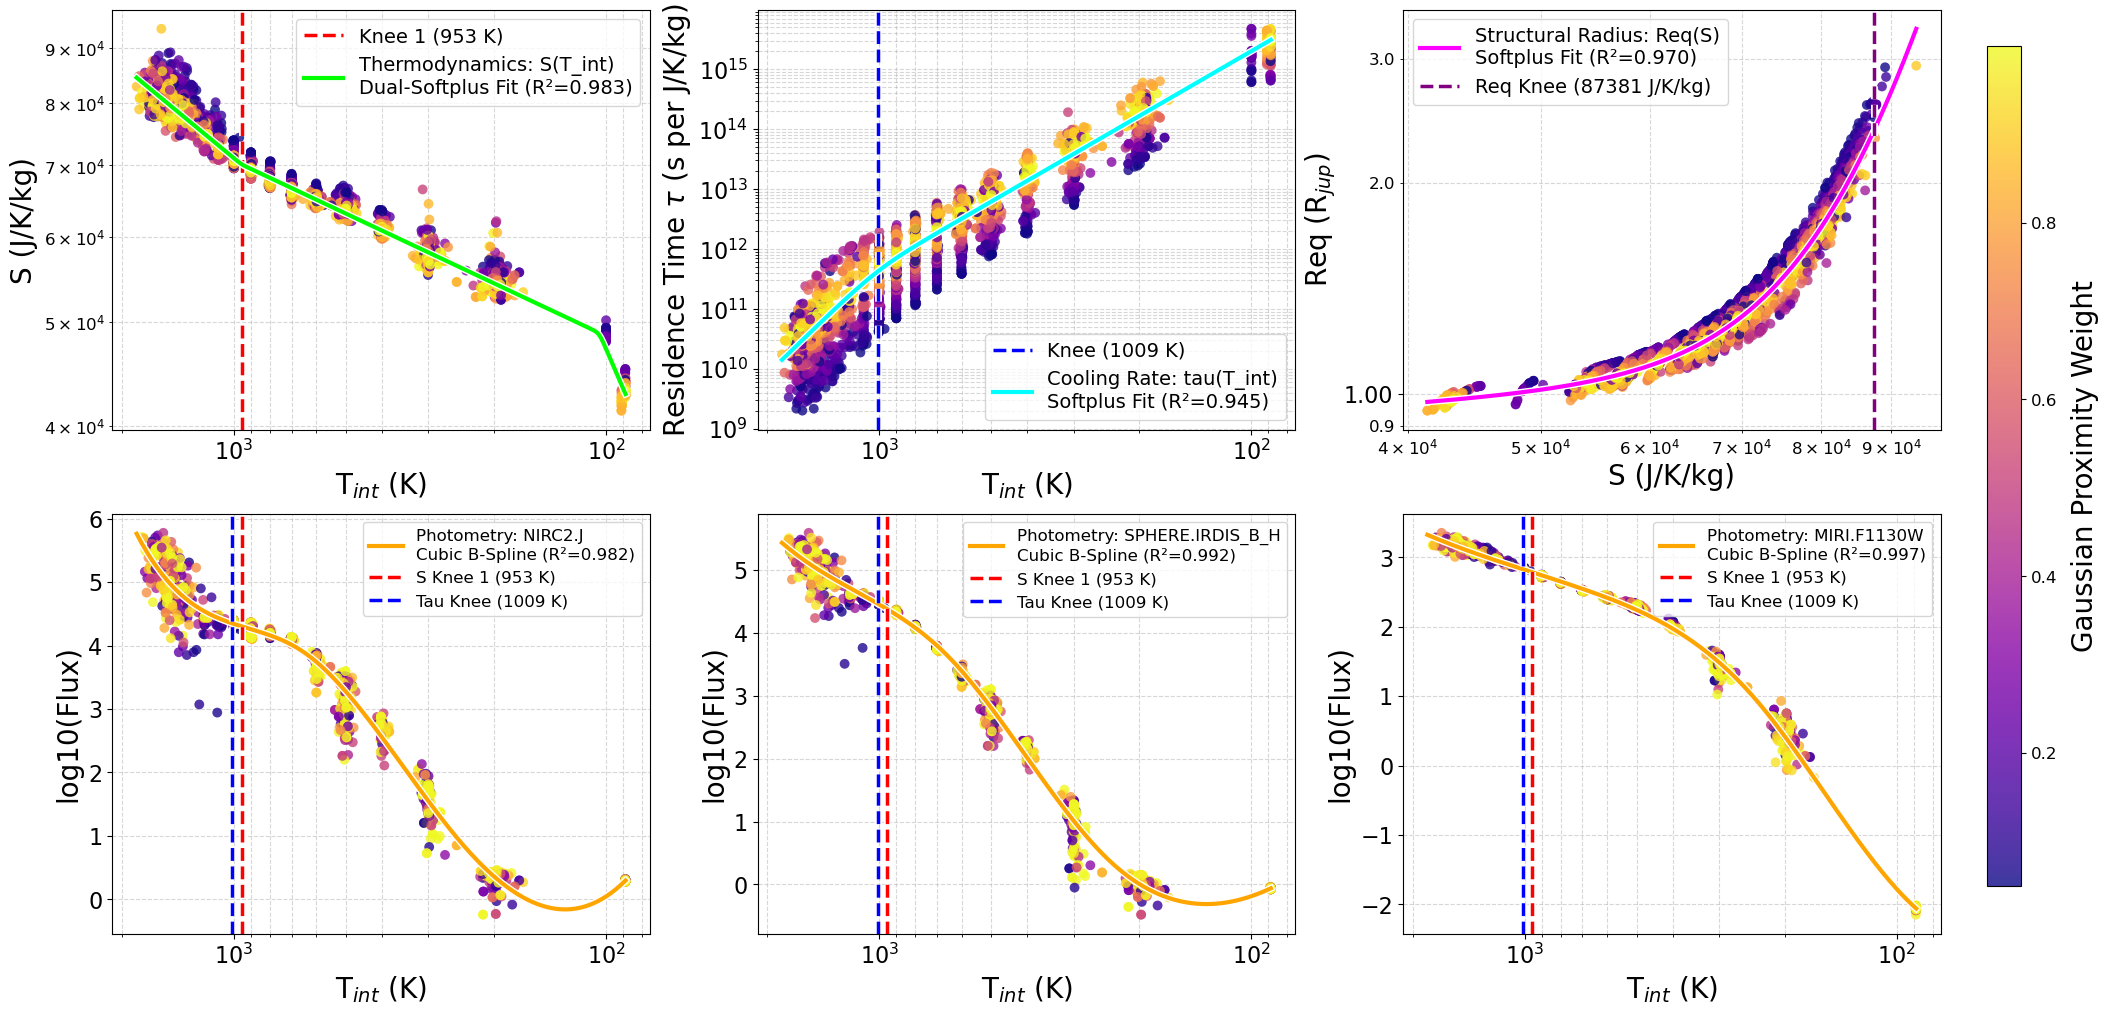

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from cooltrack.cooltrack import softplus_piecewise, dual_softplus_piecewise, quadratic_sigmoid, sloped_sigmoid
from scipy.interpolate import BSpline
from matplotlib.ticker import ScalarFormatter

# --- Markdown: ## 4. Visualize All Surrogates ---
track = fits['track_data']

# We will color the points by their Gaussian Weight to see what the fitter "cared" about
weights = track['weight'].values
scatter_kwargs = {'c': weights, 'cmap': 'plasma', 's': 50, 'edgecolors': 'none', 'alpha': 0.8, 'zorder': 2}
stroke = [pe.withStroke(linewidth=5, foreground='white')]

# Make the figure slightly wider to accommodate the new colorbar
fig, axes = plt.subplots(2, 3, figsize=(23, 12))
axes = axes.flatten()

# Pre-calculate raw values for the scatter plots
T_int_raw = np.exp(track['ln_Tint'])
S_raw = np.exp(track['ln_S'])
tau_raw = np.exp(track['ln_tau'])
Req_raw = np.exp(track['ln_Req'])

# Common smooth axes for plotting curves
x_Tint_smooth = np.linspace(track['ln_Tint'].min(), track['ln_Tint'].max(), 200)

# ---------------------------------------------------------
# Plot 1: Thermodynamics (Adaptive: Dual-Softplus, Softplus, or Linear)
# ---------------------------------------------------------
ax = axes[0]
sc = ax.scatter(T_int_raw, S_raw, **scatter_kwargs) # Save 'sc' for the colorbar later

# --- THE FIX: Dynamically handle the 3-segment Dual-Softplus ---
if fits.get('method_S') == 'dual_softplus':
    y_S_smooth = dual_softplus_piecewise(x_Tint_smooth, *fits['popt_S'])
    fit_type_S = "Dual-Softplus"
    
    # Extract the two knees and plot ONLY if > 200 K
    knee_1 = np.exp(fits['popt_S'][1])
    knee_2 = np.exp(fits['popt_S'][5])
    
    if knee_1 > 200.0:
        ax.axvline(knee_1, color='red', ls='--', lw=2.5, alpha=1.0, path_effects=stroke, label=f'Knee 1 ({knee_1:.0f} K)')
    if knee_2 > 200.0:
        ax.axvline(knee_2, color='red', ls='--', lw=2.5, alpha=1.0, path_effects=stroke, label=f'Knee 2 ({knee_2:.0f} K)')

elif fits.get('method_S') == 'softplus':
    y_S_smooth = softplus_piecewise(x_Tint_smooth, *fits['popt_S'])
    fit_type_S = "Softplus"
    
    # Extract the single knee and plot ONLY if > 200 K
    knee = np.exp(fits['popt_S'][0])
    if knee > 200.0:
        ax.axvline(knee, color='red', ls='--', lw=2.5, alpha=1.0, path_effects=stroke, label=f'Knee ({knee:.0f} K)')

else:
    y_S_smooth = fits['C'] * x_Tint_smooth + fits['D']
    fit_type_S = "Linear"

# Combine title and R2 into the legend label
label_1 = f"Thermodynamics: S(T_int)\n{fit_type_S} Fit (R²={fits['r2_S']:.3f})"
ax.plot(np.exp(x_Tint_smooth), np.exp(y_S_smooth), color='lime', lw=3, path_effects=stroke, label=label_1)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'T$_{int}$ (K)', fontsize=20)
ax.set_ylabel('S (J/K/kg)', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=14)
ax.grid(True, which="both", ls='--', alpha=0.5)
ax.invert_xaxis()

# ---------------------------------------------------------
# Plot 2: Cooling Rate (Adaptive: Softplus or Linear)
# ---------------------------------------------------------
ax = axes[1]
ax.scatter(T_int_raw, tau_raw, **scatter_kwargs)

if fits.get('method_tau') == 'softplus':
    y_tau_smooth = softplus_piecewise(x_Tint_smooth, *fits['popt_tau'])
    fit_type_tau = "Softplus"
    
    # Extract the single knee and plot ONLY if > 200 K
    knee_tau = np.exp(fits['popt_tau'][0])
    if knee_tau > 200.0:
        ax.axvline(knee_tau, color='blue', ls='--', lw=2.5, alpha=1.0, path_effects=stroke, label=f'Knee ({knee_tau:.0f} K)')
    
else:
    y_tau_smooth = fits['A'] * x_Tint_smooth + fits['B']
    fit_type_tau = "Linear"

label_2 = f"Cooling Rate: tau(T_int)\n{fit_type_tau} Fit (R²={fits['r2_tau']:.3f})"
ax.plot(np.exp(x_Tint_smooth), np.exp(y_tau_smooth), color='cyan', lw=3, path_effects=stroke, label=label_2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'T$_{int}$ (K)', fontsize=20)
ax.set_ylabel(r'Residence Time $\tau$ (s per J/K/kg)', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=14)
ax.grid(True, which="both", ls='--', alpha=0.5)
ax.invert_xaxis()

# ---------------------------------------------------------
# Plot 3: Structural Radius (Softplus in S Space)
# ---------------------------------------------------------
ax = axes[2]
ax.scatter(S_raw, Req_raw, **scatter_kwargs)

# We use the smooth entropy array derived from the thermodynamic adaptive bounds
x_S_smooth = np.linspace(track['ln_S'].min(), track['ln_S'].max(), 200)
y_R_smooth = softplus_piecewise(x_S_smooth, *fits['popt_R'])

label_3 = f"Structural Radius: Req(S)\nSoftplus Fit (R²={fits['r2_R']:.3f})"
ax.plot(np.exp(x_S_smooth), np.exp(y_R_smooth), color='magenta', lw=3, path_effects=stroke, label=label_3)

# --- THE FIX: Apply a 5% margin to ignore edge-hugging artifacts ---
ln_s_knee = fits['popt_R'][0]
min_ln_S = track['ln_S'].min()
max_ln_S = track['ln_S'].max()
domain_range = max_ln_S - min_ln_S

# Define a 5% buffer on either side of the data
margin = 0.05 * domain_range

if (min_ln_S + margin) < ln_s_knee < (max_ln_S - margin):
    knee_R = np.exp(ln_s_knee)
    ax.axvline(knee_R, color='purple', ls='--', lw=2.5, alpha=1.0, path_effects=stroke, label=f'Req Knee ({knee_R:.0f} J/K/kg)')

ax.set_xscale('log')
ax.set_yscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.set_minor_formatter(formatter)

# Standardized font sizes to match the rest of the dashboard
ax.set_xlabel('S (J/K/kg)', fontsize=20)
ax.set_ylabel(r'Req (R$_{jup}$)', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize=14)
ax.grid(True, which="both", ls='--', alpha=0.5)

# ---------------------------------------------------------
# Plots 4, 5, 6: Photometry (Adaptive Evaluation)
# ---------------------------------------------------------
tol_tirr = 50.0
target_tirr_raw = target_planet.get('T_irr', 0.0)

# Filter the raw points for visual clarity on the 2D plot
phot_track = track[np.abs(track['T_irr'] - target_tirr_raw) <= tol_tirr].copy()

target_tirr_scaled = target_tirr_raw / 100.0
X_query_phot = np.vstack([x_Tint_smooth, np.full_like(x_Tint_smooth, target_tirr_scaled)]).T

# --- Pre-extract Knees to plot on Photometry Axes (Filter > 200K) ---
knees_to_plot = []
if fits.get('method_S') == 'dual_softplus':
    knee_1 = np.exp(fits['popt_S'][1])
    if knee_1 > 200.0:
        knees_to_plot.append(('S Knee 1', knee_1, 'red'))
        
    # --- ADDED BACK: Knee 2 conditional logic ---
    knee_2 = np.exp(fits['popt_S'][5])
    if knee_2 > 200.0:
        knees_to_plot.append(('S Knee 2', knee_2, 'red'))
        
elif fits.get('method_S') == 'softplus':
    knee_S = np.exp(fits['popt_S'][0])
    if knee_S > 200.0:
        knees_to_plot.append(('S Knee', knee_S, 'red'))

if fits.get('method_tau') == 'softplus':
    knee_tau = np.exp(fits['popt_tau'][0])
    if knee_tau > 200.0:
        knees_to_plot.append(('Tau Knee', knee_tau, 'blue'))

for i, band in enumerate(photometry_bands):
    ax = axes[i + 3]
    
    clean_track = phot_track.dropna(subset=[band])
    filter_name = band.split('/')[-1]
    
    # Check if the fit exists for this band
    if clean_track.empty or fits['photometry'].get(band) is None:
        ax.text(0.5, 0.5, "No Data / Fit Failed", ha='center', va='center', transform=ax.transAxes, fontsize=14)
        continue
        
    # Scatter plot against Tint (exponential of ln_Tint)
    ax.scatter(np.exp(clean_track['ln_Tint']), clean_track[band], c=clean_track['weight'], cmap='plasma', 
               s=50, edgecolors='none', alpha=0.8, zorder=2)
    
    # --- Adaptive Prediction based on Fit Method ---
    phot_params = fits['photometry'][band]
    r2_F = phot_params['r2']

    if phot_params['method'] == 'bspline':   
        spl = BSpline(phot_params['t_knots'], phot_params['popt'], 3, extrapolate=True)
        y_F_smooth = spl(x_Tint_smooth)
        label_text = f"Photometry: {filter_name}\nCubic B-Spline (R²={r2_F:.3f})"
    elif phot_params['method'] == 'quadratic_sigmoid':   
        y_F_smooth = quadratic_sigmoid(x_Tint_smooth, *phot_params['popt']) 
        label_text = f"Photometry: {filter_name}\nQuadratic Sigmoid (R²={r2_F:.3f})"
    elif phot_params['method'] == 'sigmoid':   
        y_F_smooth = sloped_sigmoid(x_Tint_smooth, *phot_params['popt']) 
        label_text = f"Photometry: {filter_name}\nSigmoid Fit (R²={r2_F:.3f})"
    elif phot_params['method'] == 'locallinear':
        tree_model = phot_params['model']
        y_F_smooth = tree_model.predict(X_query_phot)
        label_text = f"Photometry: {filter_name}\nKD-Tree Fit (R²={r2_F:.3f})"
    else:
        y_F_smooth = softplus_piecewise(x_Tint_smooth, *phot_params['popt'])
        label_text = f"Photometry: {filter_name}\nSoftplus Fit (R²={r2_F:.3f})"
    
    # Plot the smooth predicted track
    ax.plot(np.exp(x_Tint_smooth), y_F_smooth, color='orange', lw=3, path_effects=stroke, label=label_text)
    
    # --- Plot the Knees with visual upgrades ---
    for label, knee_val, color in knees_to_plot:
        ax.axvline(knee_val, color=color, ls='--', lw=2.5, alpha=1.0, path_effects=stroke, label=f'{label} ({knee_val:.0f} K)')
    
    ax.set_xscale('log')
    ax.set_xlabel(r'T$_{int}$ (K)', fontsize=20)
    ax.set_ylabel('log10(Flux)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=16)
    
    # Adjust legend to prevent it from getting too massive with the extra lines
    ax.legend(fontsize=12, loc='best')
    
    ax.grid(True, which="both", ls='--', alpha=0.5)
    ax.invert_xaxis()

# --- Add Global Colorbar for Coherence ---
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Gaussian Proximity Weight", fontsize=20, labelpad=10)

plt.savefig("../figures/surrogate_extraction_dashboard.pdf", dpi=300, bbox_inches='tight')
plt.show()